# Comparing Precipitation Anomaly of Alabama to Historic Flood Records

---

### Overview

Here I create a map of precipitation anomaly for the month of April 1979 over Alabama. During this period Tuscaloosa, AL saw historical flooding and the dramatic rise of the the Black Warrior River. 


### Imports

In [1]:
import xarray as xr
import pandas as pd
import numpy as np
from datetime import datetime as dt
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import cartopy.crs as ccrs
import cartopy.feature as cfeature

#### Getting ERA5 data from Earth Data Hub 

In [2]:
ds= xr.open_dataset(
    "https://data.earthdatahub.destine.eu/more-era5/ecv-for-climate-change-1981-2010-anomaly-v0",
    storage_options={"client_kwargs":{"trust_env":True}},
    chunks={},
    engine="zarr",)

In [3]:
ds

<xarray.Dataset> Size: 9GB
Dimensions:     (valid_time: 561, latitude: 721, longitude: 1440)
Coordinates:
  * valid_time  (valid_time) datetime64[ns] 4kB 1979-01-01 ... 2025-09-01
  * latitude    (latitude) float64 6kB 90.0 89.75 89.5 ... -89.5 -89.75 -90.0
  * longitude   (longitude) float64 12kB 0.0 0.25 0.5 0.75 ... 359.2 359.5 359.8
Data variables:
    r           (valid_time, latitude, longitude) float32 2GB dask.array<chunksize=(24, 256, 256), meta=np.ndarray>
    siconc      (valid_time, latitude, longitude) float32 2GB dask.array<chunksize=(24, 256, 256), meta=np.ndarray>
    tp          (valid_time, latitude, longitude) float32 2GB dask.array<chunksize=(24, 256, 256), meta=np.ndarray>
    t2m         (valid_time, latitude, longitude) float32 2GB dask.array<chunksize=(24, 256, 256), meta=np.ndarray>
Attributes:
    GRIB_edition:            1
    GRIB_centre:             ecmf
    GRIB_centreDescription:  European Centre for Medium-Range Weather Forecasts
    GRIB_subCentre:          0
    Conventions:             CF-1.7
    institution:             European Centre for Medium-Range Weather Forecasts
    history:                 2025-10-07T10:14 GRIB to CDM+CF via cfgrib-0.9.1...

In [4]:
# --- Select variable ---
precip = ds['tp'] * 1000  # convert from m to mm

# --- Subset for Alabama region ---
latN, latS = 35.5, 30.0     # roughly northern/southern bounds
lonW, lonE = -89.7, -84.5   # roughly western/eastern bounds

# Convert longitudes to 0–360 if needed
if lonW < 0: lonW += 360
if lonE < 0: lonE += 360


In [5]:
precip_AL = precip.sel(latitude=slice(latN, latS), longitude=slice(lonW, lonE))

# --- Select time: April 1979 ---
precip_AL_apr79 = precip_AL.sel(valid_time="1979-04-01", method="nearest")

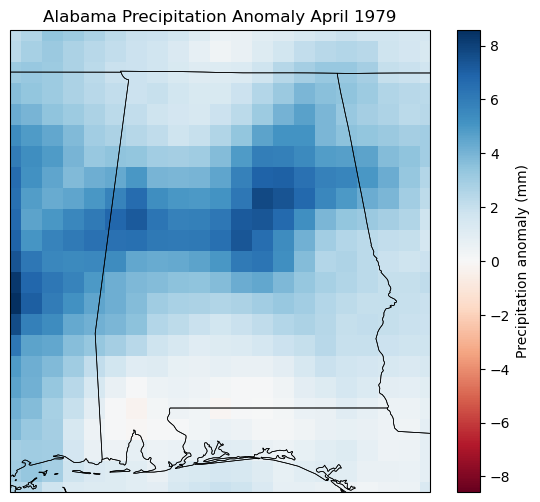

In [7]:
plt.figure(figsize=(7,6))
ax = plt.axes(projection=ccrs.PlateCarree())

# Plot data
pc = precip_AL_apr79.plot(
    ax=ax,
    transform=ccrs.PlateCarree(),
    cmap='RdBu',  # blue = positive, red = negative
    cbar_kwargs={'label': 'Precipitation anomaly (mm)'},
    add_colorbar=True,
)

# Add geographic features
ax.add_feature(cfeature.BORDERS, linewidth=0.7)
ax.add_feature(cfeature.STATES, linewidth=0.5)
ax.add_feature(cfeature.COASTLINE, linewidth=0.5)

# --- Fix: automatically set the extent to match the data ---
lon_min = float(precip_AL_apr79.longitude.min())
lon_max = float(precip_AL_apr79.longitude.max())
lat_min = float(precip_AL_apr79.latitude.min())
lat_max = float(precip_AL_apr79.latitude.max())

ax.set_extent([lon_min, lon_max, lat_min, lat_max], crs=ccrs.PlateCarree())

ax.set_title("Alabama Precipitation Anomaly April 1979", fontsize=12)
plt.show()


#### References

https://pubs.usgs.gov/publication/ofr811057

